<a href="https://colab.research.google.com/github/scelliot-cpu/Elliott_DSPN_26_FinalProject/blob/main/Elliott_DSPN_S26_FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# How Age and Reaction Time Influence Sensorimotor Adaptation


##Background
Sensorimotor adaptation is the process by which individuals adjust their movements in response to altered sensory feedback. In this dataset, participants completed a visuomotor rotation task where the cursor was rotated relative to hand movement.

This project investigates how individual differences in age and reaction time relate to motor adaptation. Understanding these relationships can provide insight into how learning and motor control change across development. This project uses data from *Large-scale citizen science reveals predictors of sensorimotor adaptation*. Participants completed a web-based visuomotor rotation task in which they made reaching movements to move a cursor towards a visual target on the screen (Figure 1). The cursor's projectory was systematically rotated away from their actual hand movement, forcing them to gradually adjust their movement to account for the error. Over repeated trials, researchers measured how well and how quickly participants adapted to this error, along with collecting basic demographic information through a survey.

###Figure 1: Schematic of the Sensorimotor Task

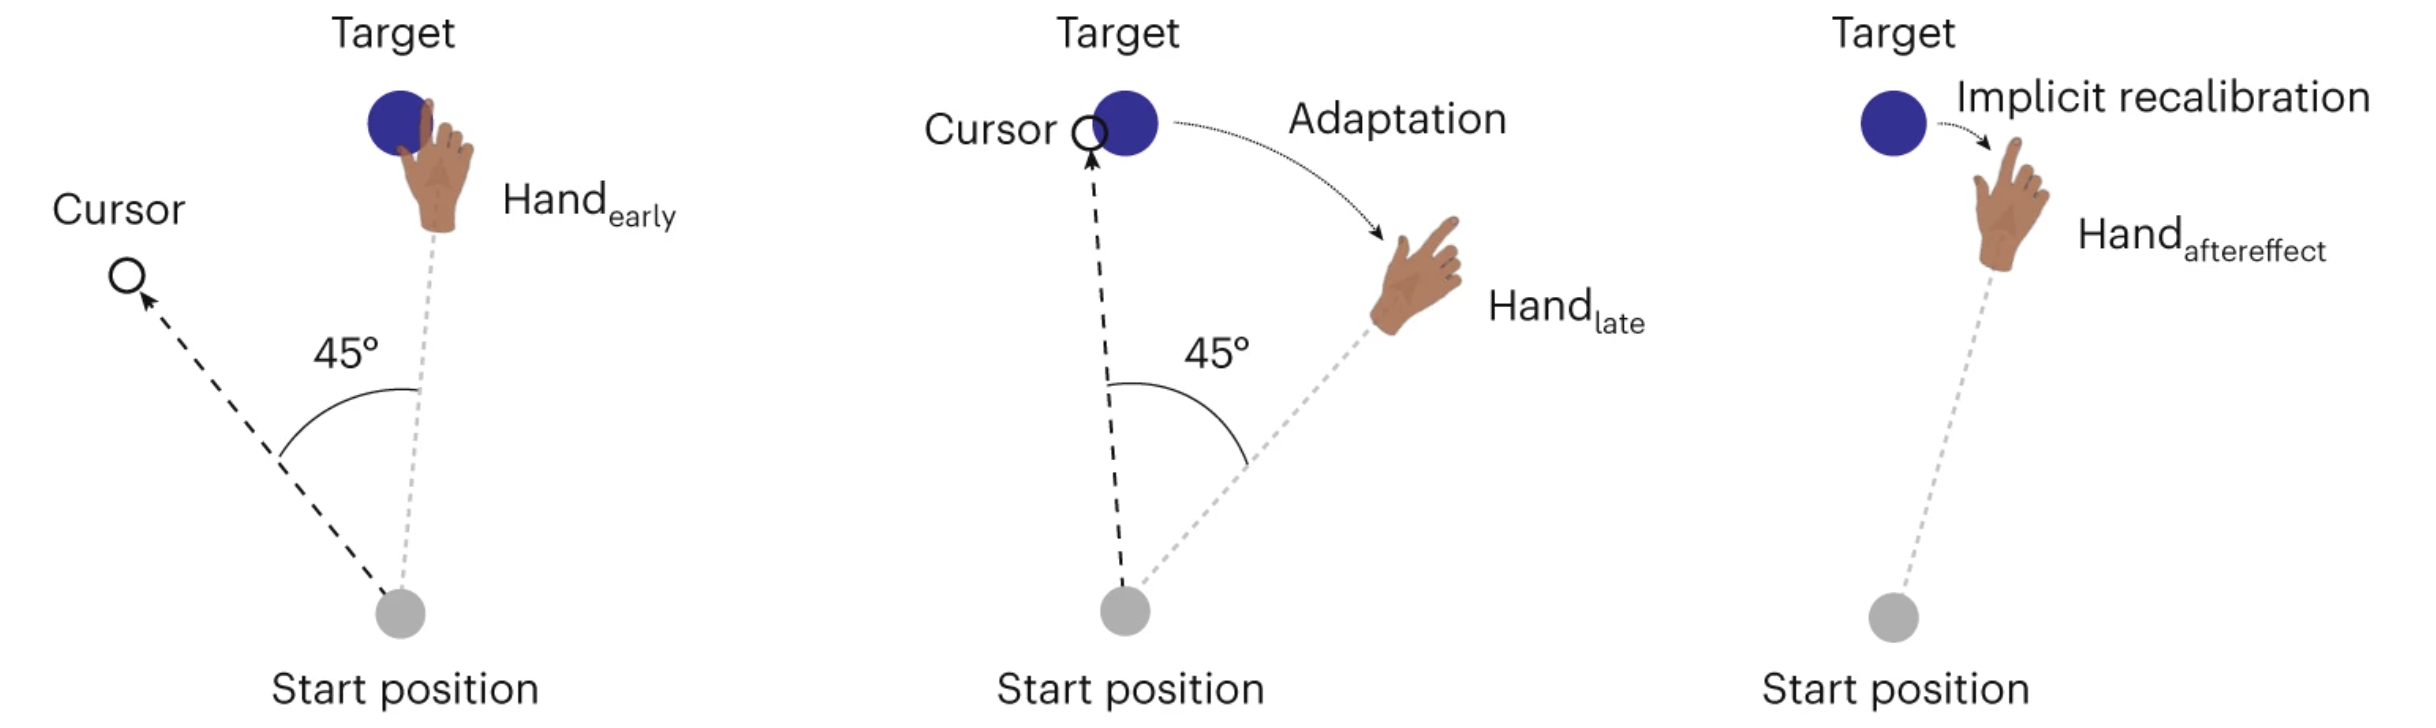

#Variables

###Dataset Structure

The raw dataset is trial-level, meaning that each row corresponds to one trial from one participant. Each participant contributes multiple trials across baseline, adaptation, and aftereffect phases.

The analysis was restricted to participants classified as children (<18 years) and young adults (18-30 years). After filtering, the dataset included:

*   4080 participants
*   1360 total trial-level observations

For modeling purposes, trial-level data was also aggregated into participant-level summaries, resulting in 4080 observations in the final dataset.



**Participant-Level Variables:**

*   `Subject.ID`: unique participant identifier
*   `Age`: years reported by participant


**Trial-Level Task Variables:**

*   `TN`: Trial number within the experiment
*   `Block`: Experimental block corresponding to the task phase
*   `ST`: Search time, defined as the time required to return the cursor to the srarting position
*   `RT`: Reaction time, defined as the time it takes to initiate movement
*   `MT`: Movement time, defined as the time it takes to reach the target from movement initiation
*   `ri`: Size of rotation
*   `HandFlip`: Hand angle used as a measure of motor adaptation, where larger values indiciate greater compensation for the imposed rotation


**Derived Variables**


*   `Stage`: Task stage, defined based on experimental block and trial position
    *   Baseline: Trials with veridical feedback
    *   Early Adaptation: First trials during the rotation phase
    *   Late Adaptation: Last trials during rotation phase
    *   Aftereffect: No-feedback trials following adaptation

*   `Group`: Age group

    *   Child: Age < 18
    *   Young Adult: 18 $ \le $ Age $ \le $ 30


**Self-Reported Variables**

*   `Clumsy`: Self-reported clumsiness
*   `Videogames`: Frequency of video game usage
*   `Sleep`: Self-reported sleep duration
*   `ComputerUsage`: Frequency of computer usage

These variables were used in exploratory models to assess whether behavioral and lifestyle factors are associated with motor performance.










#Hypotheses
**Main Analysis**
*   Children will show reduced early motor adaptation compared to young adults.
*   Children will show reduced late motor adaptation compared to young adults.
*   Children will show smaller aftereffects than young adults.

These hypotheses will be tested by comparing groups across adaptation stages using:


$$
Outcome = \beta_0 + \beta_1(Group) + \beta_2(Stage) + \beta_3(Group \times Stage) + \epsilon
$$


**Secondary Analysis**
*   Children will show slower baseline performance (MT, RT, ST) than young adults

**Exploratory Analysis**

*   Behavioral and demographic variables (e.g., clumsiness, sleep, video game use) will be associated with motor performance.







#Data Plan Organization

###Data Architecture
The dataset is structured at the trial level with repeated observations per participant across task phases

###Data Cleaning
0.   Import the dataset from Google Drive
1.   Define developmental groups by creating the **Group** variable:
     *   Child: participants younger than 18
      *   YoungAdult: participants ages 18-30
      * Remove participants who do not fall in either age group.

2.   Define task phases using the **Block** variable and create the **Stage** variable to identify Baseline, Early Adaptation, Late Adapation, and Aftereffect phases.
3. Aggregate trial-level data into participant-level summary tables for analysis.
4. Check the final dataset for missing values or anomalies.
5. Verify that the final dataset follows tidy data principles.







In [14]:
install.packages(c("googledrive", "tidyverse", "ggplot2", "dplyr"))

library(googledrive)
library(tidyverse)
library(ggplot2)
library(dplyr)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



###0. Import Dataset From Google Drive

In [15]:
file_id <- "1o4Hgv1CyToFkHTmtSoyfyV3r2j9tLsrS"

url <- paste0("https://drive.google.com/uc?id=", file_id)

data <- read.csv(url)

head(data)

,TN,Subject.ID,ST,RT,MT,ti,ri,Group,CCW,numtar,⋯,screenheight,screenwidth,endtime,clumsy,seedisplay,videogames,major,Sleep,ComputerUsage,gameIndex
,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>,<int>,⋯,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>
1,1,02a12b38-eabd-4291-b58a-ca6fa0910470,2164,736,256,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
2,2,02a12b38-eabd-4291-b58a-ca6fa0910470,907,366,663,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
3,3,02a12b38-eabd-4291-b58a-ca6fa0910470,1101,298,308,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
4,4,02a12b38-eabd-4291-b58a-ca6fa0910470,992,294,39,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
5,5,02a12b38-eabd-4291-b58a-ca6fa0910470,2400,165,184,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy
6,6,02a12b38-eabd-4291-b58a-ca6fa0910470,1469,96,217,0,0,/static/js/cw45tar0_tgtfile_5Dec2020_V1.json,FALSE,1,⋯,722,1536,3/29/2021 10:8.47.986,Disagree,yes,Agree,Psychology,6,9,easy


###1. Define Developmental Groups

In [16]:
clean_data <- data %>%
  mutate(Group = case_when(
  Age < 18 ~ "Child",
  Age >= 18 & Age <=30 ~ "YoungAdult"
  )) %>%
  filter(!is.na(Group))

###2. Define Task Stages

In [17]:
clean_data <- clean_data %>%
  mutate(Phase = case_when(
    Block == 1 ~ "Baseline",
    Block == 2 ~ "Adaptation",
    Block == 3 ~ "Aftereffect",
    Block == 4 ~ "OppositeAdaptation",
  ))

clean_data <- clean_data %>%
  group_by(Subject.ID, Phase) %>%
  mutate(Trial_in_Phase = row_number()) %>%
  ungroup()

clean_data <- clean_data %>%
  mutate(Stage = case_when(
    Phase == "Adaptation" & Trial_in_Phase <= 10 ~ "Early Adaptation",
    Phase == "Adaptation" & Trial_in_Phase > 10 ~ "Late Adaptation",
    TRUE ~ Phase
  ))

  head(clean_data)

TN,Subject.ID,ST,RT,MT,ti,ri,Group,CCW,numtar,⋯,clumsy,seedisplay,videogames,major,Sleep,ComputerUsage,gameIndex,Phase,Trial_in_Phase,Stage
<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<chr>,<lgl>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>,<int>,<chr>
1,02a12b38-eabd-4291-b58a-ca6fa0910470,2164,736,256,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,1,Baseline
2,02a12b38-eabd-4291-b58a-ca6fa0910470,907,366,663,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,2,Baseline
3,02a12b38-eabd-4291-b58a-ca6fa0910470,1101,298,308,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,3,Baseline
4,02a12b38-eabd-4291-b58a-ca6fa0910470,992,294,39,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,4,Baseline
5,02a12b38-eabd-4291-b58a-ca6fa0910470,2400,165,184,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,5,Baseline
6,02a12b38-eabd-4291-b58a-ca6fa0910470,1469,96,217,0,0,YoungAdult,FALSE,1,⋯,Disagree,yes,Agree,Psychology,6,9,easy,Baseline,6,Baseline


In [27]:
clean_data <- clean_data %>%
  mutate(HandAngle = HandFlip)

###3. Aggregate trial-level data into participant-level dataset.

In [28]:
summary_data <- clean_data %>%
  filter(Stage %in% c("Early Adaptation", "Late Adaptation", "Aftereffect")) %>%
  group_by(Subject.ID, Group, Stage) %>%
  summarise(
    mean_MT = mean(MT, na.rm = TRUE),
    mean_RT = mean(RT, na.rm = TRUE),
    mean_ST = mean(ST, na.rm = TRUE),
    mean_angle = mean(HandFlip, na.rm = TRUE),
    .groups = "drop"
  )

head(summary_data)



Subject.ID,Group,Stage,mean_MT,mean_RT,mean_ST,mean_angle
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Aftereffect,36.33333,303.8333,2567.333,13.039709
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Early Adaptation,112.90000,327.6000,2153.700,23.268919
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Late Adaptation,47.56818,170.5227,1954.512,38.604005
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Aftereffect,62.33333,296.1667,1426.833,2.495032
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Early Adaptation,58.50000,300.8889,2014.500,39.027923
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Late Adaptation,58.84091,217.3864,1886.318,39.834128


###4. Check the final dataset for missing values or anomalies


In [19]:
colSums(is.na(summary_data))

table(summary_data$Group, summary_data$Stage)

Subject.ID      Group      Stage    mean_MT    mean_RT    mean_ST 
         0          0          0          0          0          0

            
             Aftereffect Early Adaptation Late Adaptation
  Child              422              422             422
  YoungAdult         938              938             938

###5. Verify the final dataset follows tidy data principles


In [20]:
head(summary_data)

nrow(summary_data)
n_distinct(summary_data$Subject.ID)

summary_data %>%
  count(Subject.ID, Stage) %>%
  filter(n > 1)

Subject.ID,Group,Stage,mean_MT,mean_RT,mean_ST
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Aftereffect,36.33333,303.8333,2567.333
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Early Adaptation,112.90000,327.6000,2153.700
0017086b-c53c-4705-9dbc-48a6f3c45f90,YoungAdult,Late Adaptation,47.56818,170.5227,1954.512
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Aftereffect,62.33333,296.1667,1426.833
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Early Adaptation,58.50000,300.8889,2014.500
00527f0a-8fe5-42b9-9e5a-3b81e8907a2c,Child,Late Adaptation,58.84091,217.3864,1886.318


[1] 4080

[1] 1360

Subject.ID,Stage,n
<chr>,<chr>,<int>


The final dataset contains 4080 observations acrtoss 1360 participants, with each participant contributing one observation per stage. The dataset satisfies tidy data principles:

*   Each row represents a single participant-stage observation
*   Each column represents a single variable
*   Each participant contributes exactly one observation per stage
*   No dublicate or missing values are present





#Statistical Analysis
This project includes three levels of analysis:

1. Main analysis comparing groups across adaptation stages
2. Secondary analysis examining baseline differences
3. Exploratory analysis testing behavioral predictors of performance

##Main Analysis


####Hand Angle Across Adaptation Stages

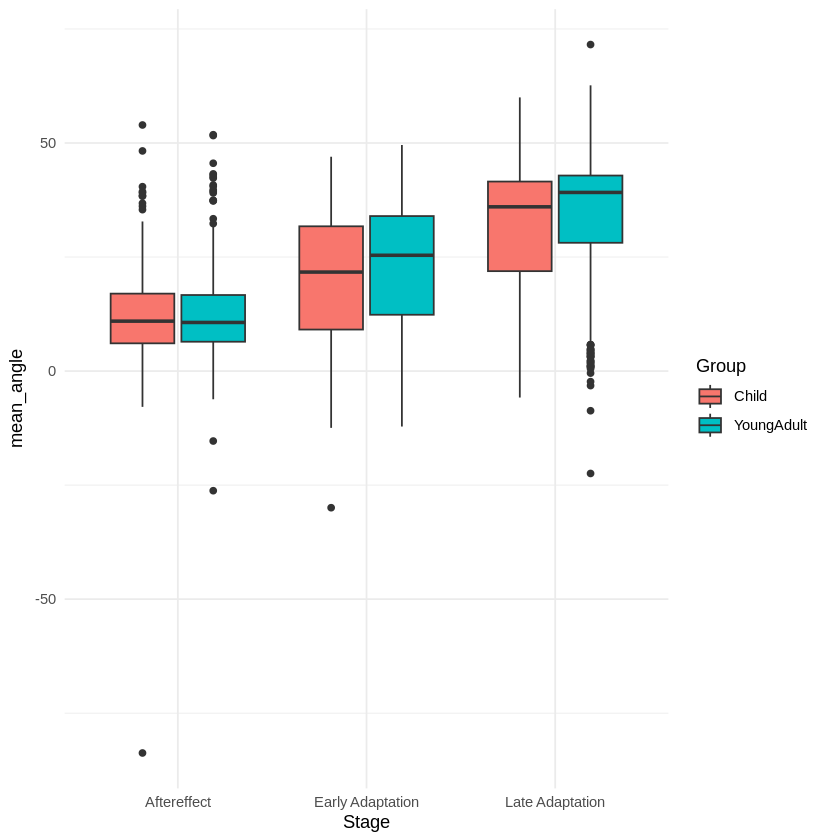

In [29]:
ggplot(summary_data, aes(x = Stage, y = mean_angle, fill = Group)) +
  geom_boxplot() +
  theme_minimal()

The boxplot shows that hand angle increases from early adaptation to late adaptation, indicating that participants progressively adjust their movement to compensate for rotation.

Both age groups show this pattern of increasing hand angle, suggesting successful motor adaptation across stages. Young adults appear to have slightly larger hand angles, particularly in late adaptation, though variability within groups is substantial.

In [30]:
model_angle <- lm(mean_angle ~ Group * Stage, data = summary_data)

summary(model_angle)


Call:
lm(formula = mean_angle ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-95.773  -7.172   1.348   8.346  41.906 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                            12.0407     0.5631  21.381  < 2e-16 ***
GroupYoungAdult                         0.1521     0.6781   0.224  0.82255    
StageEarly Adaptation                   8.8639     0.7964  11.130  < 2e-16 ***
StageLate Adaptation                   19.5259     0.7964  24.518  < 2e-16 ***
GroupYoungAdult:StageEarly Adaptation   2.2093     0.9590   2.304  0.02128 *  
GroupYoungAdult:StageLate Adaptation    2.7976     0.9590   2.917  0.00355 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 11.57 on 4074 degrees of freedom
Multiple R-squared:  0.3679,	Adjusted R-squared:  0.3671 
F-statistic: 474.2 on 5 and 4074 DF,  p-value: < 2.2e-16


The linear model reveals a significant effect of Stage, with hand angle increasing significantly during both early adaptation (β = 8.86, p < 0.001) and late adaptation (β = 19.53, p < 0.001) relative to the aftereffect stage. This indicates that participants profressive adjust their movements over time, consistent with motor learning.

There is no signficant main effect of Group (p=0.82), suggesting that overall adaptation levels are similar between children and young adults.

There are significant Group x Stage interactions for both early adaptation (β = 2.21, p = 0.021) and late adaptation (β = 2.80, p = 0.004). These results indicate that young adults exhibit slightly greater adaptation that children during both early and late stages.

The R^2 value is relatively high (0.368), indicating that the model explains a substantial portion of variance in hand angle, further supporting the robustness of these findings.

**Interpretation**

These results provide partial support for the main hypotheses.



*   Young adults show significantly greater adaptation than children during early adaptation.
*   Young adults show significantly greater adaptation than children during late adaptation.
*  There is no significant group difference in the aftereffect stage.

####Movement Time Across Adaptation Stages

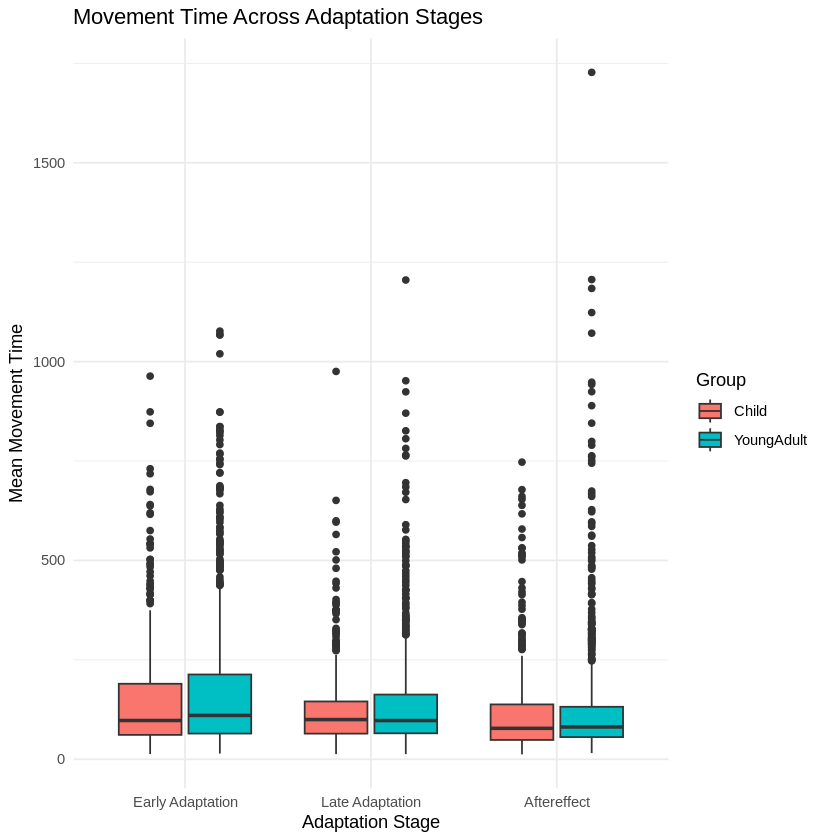

In [25]:
summary_data$Stage <- factor(summary_data$Stage,
  levels = c("Early Adaptation", "Late Adaptation", "Aftereffect")
)

ggplot(summary_data, aes(x = Stage, y = mean_MT, fill = Group)) +
  geom_boxplot() +
  theme_minimal() +
  labs(
    title = "Movement Time Across Adaptation Stages",
    x = "Adaptation Stage",
    y = "Mean Movement Time"
  )

In [22]:
model_mt <- lm(mean_MT ~ Group * Stage, data = summary_data)

summary(model_mt)


Call:
lm(formula = mean_MT ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-159.37  -79.09  -47.16   20.05 1598.30 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                            121.431      7.021  17.294  < 2e-16 ***
GroupYoungAdult                          7.602      8.455   0.899 0.368625    
StageEarly Adaptation                   33.316      9.930   3.355 0.000801 ***
StageLate Adaptation                     7.699      9.930   0.775 0.438157    
GroupYoungAdult:StageEarly Adaptation   11.424     11.957   0.955 0.339397    
GroupYoungAdult:StageLate Adaptation     1.332     11.957   0.111 0.911272    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 144.2 on 4074 degrees of freedom
Multiple R-squared:  0.01659,	Adjusted R-squared:  0.01538 
F-statistic: 13.74 on 5 and 4074 DF,  p-value: 2.471e-13


The linear model shows a significant effect of stage, with movement time highest during early adaptation (p < 0.001), indicating increased difficulty during initial learning. No significant effect of group or Group × Stage interaction is observed, suggesting that children and young adults exhibit similar performance across stages.

####Reaction Time Across Adaptation Stages

In [24]:
model_rt <- lm(mean_RT ~ Group * Stage, data = summary_data)

summary(model_rt)


Call:
lm(formula = mean_RT ~ Group * Stage, data = summary_data)

Residuals:
    Min      1Q  Median      3Q     Max 
-256.52  -66.21  -11.19   49.70  739.81 

Coefficients:
                                      Estimate Std. Error t value Pr(>|t|)    
(Intercept)                            283.819      4.933  57.538  < 2e-16 ***
GroupYoungAdult                         13.369      5.940   2.251   0.0245 *  
StageEarly Adaptation                   12.480      6.976   1.789   0.0737 .  
StageLate Adaptation                   -39.052      6.976  -5.598 2.31e-08 ***
GroupYoungAdult:StageEarly Adaptation    5.536      8.400   0.659   0.5099    
GroupYoungAdult:StageLate Adaptation    -8.818      8.400  -1.050   0.2939    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 101.3 on 4074 degrees of freedom
Multiple R-squared:  0.06518,	Adjusted R-squared:  0.06403 
F-statistic: 56.81 on 5 and 4074 DF,  p-value: < 2.2e-16


Reaction time decreases significantly during late adaptation (p < 0.001), indicating improved efficiency over time. A small main effect of group is observed (p = 0.025), but no significant interaction is found, suggesting similar patterns of change across stages for both groups.
